# `evap_cool` — evaporative cooling runs & figures

Semiclassical evaporative cooling for ideal quantum and classical gases. Each
trap is run under all three statistics — **Maxwell–Boltzmann (MB)**,
**Bose–Einstein (BE)**, **Fermi–Dirac (FD)** — across five geometries:

| key | geometry | exponent $\nu$ | units |
|---|---|---|---|
| `box` | 3D box | 3/2 | J (SI) |
| `box2d_osc1d` | 2D box + 1D harmonic | 2 | J (SI) |
| `osc2d_box1d` | 2D harmonic + 1D box | 5/2 | J (SI) |
| `oscillator` | 3D harmonic | 3 | eV |
| `quadrupole` | 3D quadrupole (linear) | 9/2 | eV |

The two **mixed** geometries (`box2d_osc1d`, `osc2d_box1d`) collapse to a single
power-law density of states, so they reuse the entire generic machinery with a
non-standard $\nu$. They run in SI units with a literal global volume $V_g$
(default $(100\,\mu\mathrm{m})^3$); $V_g$ only sets the scale of $P$ and
$\kappa_T$, nothing else.

Runs are saved to a timestamped session folder; per-trap overview figures go to
`session/figures/`.

> Cross-trap normalisation — collapsing every trap/statistic onto one plot — is
> handled in a separate notebook, not here.

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

from evap_cool import (
    # constants & traps (the two mixed traps are new)
    ConstantsSI, ConstantsEV,
    BoxTrap, QuadrupoleTrap, OscillatorTrap, OscBoxTrap, BoxOscTrap,
    # initial-state and run helpers
    create_result_dict, create_mb_result_dict, build_cutoff_schedule,
    initialize_quantum_state, initialize_mb_state,
    run_quantum_evaporation, run_mb_evaporation,
    # two-stage zoom wrappers (BEC cliff / Fermi degeneracy)
    run_with_bec_zoom, run_with_fermi_zoom, ZoomOutcome,
    # I/O — timestamped session folders avoid overwriting across re-runs
    make_session_dir, save_run, load_run, list_runs, list_sessions,
    # post-processing thermodynamics
    process_and_save_run, process_and_save_mb_run, load_thermodynamics,
    # plots
    plot_combined_overview,
)

#mp.dps = 15

# One timestamped folder per notebook execution, e.g. runs/2026-06-05/14h32m17s/
session = make_session_dir(base="runs")
fig_dir = session / "figures"
fig_dir.mkdir(exist_ok=True)
print(f"Session folder : {session}")
print(f"Figures folder : {fig_dir}")

Session folder : runs\2026-06-06\01h38m23s
Figures folder : runs\2026-06-06\01h38m23s\figures


## The unified pipeline

For every trap we run the same steps: solve the initial $(\mu_0, E_0, \Omega_0)$
consistent with $(N_0, T_0)$ for each statistic; build a cut-off schedule; run
BE, FD and MB; plot the overview; and (optionally) persist all three runs plus
the overview figure.

`run_trap_session` keeps the tested two-stage **zoom** behaviour: bosons go
through `run_with_bec_zoom` and fermions through `run_with_fermi_zoom` (a coarse
pass, then — if it halts near degeneracy — a finer, higher-precision pass
re-seeded a few steps earlier). Set `zoom=False` for a single quick pass.

The file stem defaults to `name.lower()`; we pass an explicit `stem` so the
saved filenames match the canonical trap `key` shared with the thermo notebook.

In [3]:
def solve_initial_quantum_state(trap, N0, T0, sign, **kw):
    """Return (mu0, E0, Omega0) consistent with (N0, T0) for the given statistics."""
    alpha0 = trap.solve_alpha0(N0, T0, sign=sign, **kw)
    mu0    = alpha0 * trap.kB * T0
    E0     = float(trap.equilibrium_E(T0, mu0, sign).real)
    Omega0 = float(trap.equilibrium_Omega(T0, mu0, sign).real)
    return mu0, E0, Omega0


def run_trap_session(
    trap, name, *,
    N0, T0,
    Q0, dQ_coarse, n_steps_coarse,
    dQ_fine, n_steps_fine,
    session=None, stem=None,
    alpha_floor_coarse=-1e-3,
    alpha_floor_fine=-1e-15,
    dps_coarse = 20,dps_fine=80, backoff=5,
    dT=1e-20, dmu=1e-30,
    show_plot=True, save_fig=False, fig_dir=None,
    zoom=True, save=False,
):
    """Run BE / FD / MB on `trap`; optionally save the runs and the overview figure."""
    if stem is None:
        stem = name.lower().replace(" ", "_")
    if save and session is None:
        raise ValueError("`session` must be provided when save=True.")
    print(f"\n=== {name}  ({stem}) ===")

    # 1. Initial states for the two quantum statistics.
    mu0_b, E0_b, Omega0_b = solve_initial_quantum_state(trap, N0, T0, sign=+1)
    mu0_f, E0_f, Omega0_f = solve_initial_quantum_state(trap, N0, T0, sign=-1, alpha_hi=20.0)
    print(f"  alpha0 (bosons)   = {mu0_b/(trap.kB*T0):+.4f}")
    print(f"  alpha0 (fermions) = {mu0_f/(trap.kB*T0):+.4f}")

    # 2. Coarse Q-schedule (used by FD, MB, and stage 1 of bosons when zooming).
    Q_schedule = build_cutoff_schedule(Q0=Q0, dQ=dQ_coarse, n_steps=n_steps_coarse)

    # 3a. Bosons.
    if zoom:
        res_b, zoom_b = run_with_bec_zoom(
            trap, N0=N0, T0=T0, mu0=mu0_b, E0=E0_b, Omega0=Omega0_b,
            Q0=Q0, dQ_coarse=dQ_coarse, n_steps_coarse=n_steps_coarse,
            dQ_fine=dQ_fine, n_steps_fine=n_steps_fine,
            dT=dT, dmu=dmu, sign=+1,
            alpha_floor_coarse=alpha_floor_coarse, alpha_floor_fine=alpha_floor_fine,
            dps_coarse=dps_coarse, dps_fine=dps_fine, backoff=backoff, verbose=False,
        )
        out_b = zoom_b
    else:
        res_b = create_result_dict(); res_b["Q"] = list(Q_schedule)
        initialize_quantum_state(res_b, N0, T0, mu0_b, E0_b, Omega0_b)
        out_b = run_quantum_evaporation(
            res_b, trap, N0, n_steps=n_steps_coarse, dT=dT, dmu=dmu, sign=+1,
            alpha_floor=alpha_floor_coarse, verbose=False,
        )
        zoom_b = None

    # 3b. Fermions.
    if zoom:
        res_f, zoom_f = run_with_fermi_zoom(
            trap, N0=N0, T0=T0, mu0=mu0_f, E0=E0_f, Omega0=Omega0_f,
            Q0=Q0, dQ_coarse=dQ_coarse, n_steps_coarse=n_steps_coarse,
            dQ_fine=dQ_fine, n_steps_fine=n_steps_fine,
            dT=dT, dmu=dmu, sign=-1,
            dps_coarse=dps_coarse, dps_fine=dps_fine, backoff=backoff, verbose=False,
        )
        out_f = zoom_f
        n_steps_total = out_f.n_total_committed
    else:
        res_f = create_result_dict(); res_f["Q"] = list(Q_schedule)
        initialize_quantum_state(res_f, N0, T0, mu0_f, E0_f, Omega0_f)
        out_f = run_quantum_evaporation(
            res_f, trap, N0, n_steps=n_steps_coarse, dT=dT, dmu=dmu, sign=-1, verbose=False,
        )
        zoom_f = None
        n_steps_total = n_steps_coarse

    # 3c. Maxwell-Boltzmann reference.
    Q_schedule_mb = build_cutoff_schedule(Q0=Q0, dQ=dQ_coarse, n_steps=n_steps_total)
    res_mb = create_mb_result_dict(); res_mb["Q"] = list(Q_schedule_mb)
    initialize_mb_state(res_mb, N0, T0)
    run_mb_evaporation(res_mb, trap, N0, n_steps=n_steps_total, verbose=False)

    n_b = zoom_b.n_total_committed if zoom_b is not None else out_b.n_completed
    n_f = zoom_f.n_total_committed if zoom_f is not None else out_f.n_completed
    print(f"  committed : bosons={n_b}  fermions={n_f}  mb={n_steps_total}")

    # 4. Overview figure (overlay BE / FD / MB), shown and/or saved.
    if show_plot or save_fig:
        fig = plot_combined_overview(res_b, res_f, res_mb, trap_name=name, n_b=n_b, n_f=n_f)
        if save_fig:
            d = fig_dir if fig_dir is not None else (session / "figures")
            d.mkdir(exist_ok=True)
            fig.savefig(d / f"{stem}_overview.pdf", bbox_inches="tight")
            fig.savefig(d / f"{stem}_overview.png", dpi=200, bbox_inches="tight")
            print(f"  figure    -> {(d / f'{stem}_overview.pdf').relative_to(session)} (+ .png)")
        if show_plot:
            plt.show()
        else:
            plt.close(fig)

    # 5. Save all three runs into the session, stems == key.
    if save:
        common = dict(
            N0=N0, T0=T0, Q0=Q0, dQ=dQ_coarse, n_steps=n_steps_coarse,
            dQ_fine=dQ_fine, n_steps_fine=n_steps_fine,
            alpha_floor_coarse=alpha_floor_coarse, alpha_floor_fine=alpha_floor_fine,
            dps_fine=dps_fine, backoff=backoff, zoom=zoom,
        )
        boson_extra   = {"zoom": zoom_b.to_metadata()} if zoom_b is not None else None
        fermion_extra = {"zoom": zoom_f.to_metadata()} if zoom_f is not None else None
        save_run(res_b, session / f"{stem}_bosons.json", trap=trap,
                 parameters={**common, "mu0": mu0_b, "E0": E0_b, "Omega0": Omega0_b, "sign": +1},
                 outcome=out_b, extra_metadata=boson_extra)
        save_run(res_f, session / f"{stem}_fermions.json", trap=trap,
                 parameters={**common, "mu0": mu0_f, "E0": E0_f, "Omega0": Omega0_f, "sign": -1},
                 outcome=out_f, extra_metadata=fermion_extra)
        save_run(res_mb, session / f"{stem}_mb.json", trap=trap,
                 parameters={**common, "sign": 0}, outcome=None)

    return {"bosons": (res_b, out_b), "fermions": (res_f, out_f), "mb": (res_mb, None)}

## Trap roster

Defined once and reused by the thermo notebook (same `key` → same filename
stems, same trap parameters). The two mixed traps use SI units; the harmonic
and quadrupole traps default to eV.

> Mixed-trap note: with the default geometry and `N0=1e7` these sit in the
> near-classical regime ($\alpha_0 \lesssim -10$), so their BE/FD curves track
> MB closely and the zoom won't trigger a fine pass. Shrink `L`/`Sigma` or the
> frequencies (or raise `N0`) to push them toward degeneracy.

In [13]:
TRAPS = [
    dict(key="box",         name="Box",            units="J",
         trap=BoxTrap(V=1e-11)),
    dict(key="box2d_osc1d", name="2D box + 1D HO", units="J",
         trap=BoxOscTrap(omega_z=2*np.pi*100, Sigma=1e-8)),
    dict(key="osc2d_box1d", name="2D HO + 1D box", units="J",
         trap=OscBoxTrap(omega_x=2*np.pi*100, omega_y=2*np.pi*100, L=1e-4)),
    dict(key="oscillator",  name="Oscillator",     units="eV",
         trap=OscillatorTrap(omega=2*np.pi*100)),
    dict(key="quadrupole",  name="Quadrupole",     units="eV",
         trap=QuadrupoleTrap(A_bar=1e-15)),
]

for t in TRAPS:
    tr = t["trap"]
    print(f"  {t['key']:14s} s={tr.s:<4} V_g={tr.volume_global:.3g}  kB={tr.kB:.4g}  ({t['units']})")

  box            s=1.5  V_g=1e-11  kB=1.381e-23  (J)
  box2d_osc1d    s=2.0  V_g=1e-12  kB=1.381e-23  (J)
  osc2d_box1d    s=2.5  V_g=1e-12  kB=1.381e-23  (J)
  oscillator     s=3.0  V_g=4.03e-09  kB=8.617e-05  (eV)
  quadrupole     s=4.5  V_g=1e+45  kB=8.617e-05  (eV)


## Run all traps (BE / FD / MB)

One call per trap, looping over the roster. Each call runs the three statistics,
shows the overview, and saves the runs + figure into the session.

To iterate quickly, reduce `n_steps_coarse` (and/or set `zoom=False`), or slice
`TRAPS` to run a single geometry.


=== Oscillator  (oscillator) ===
  alpha0 (bosons)   = -11.6359
  alpha0 (fermions) = -11.6359
  committed : bosons=9932  fermions=10033  mb=10033


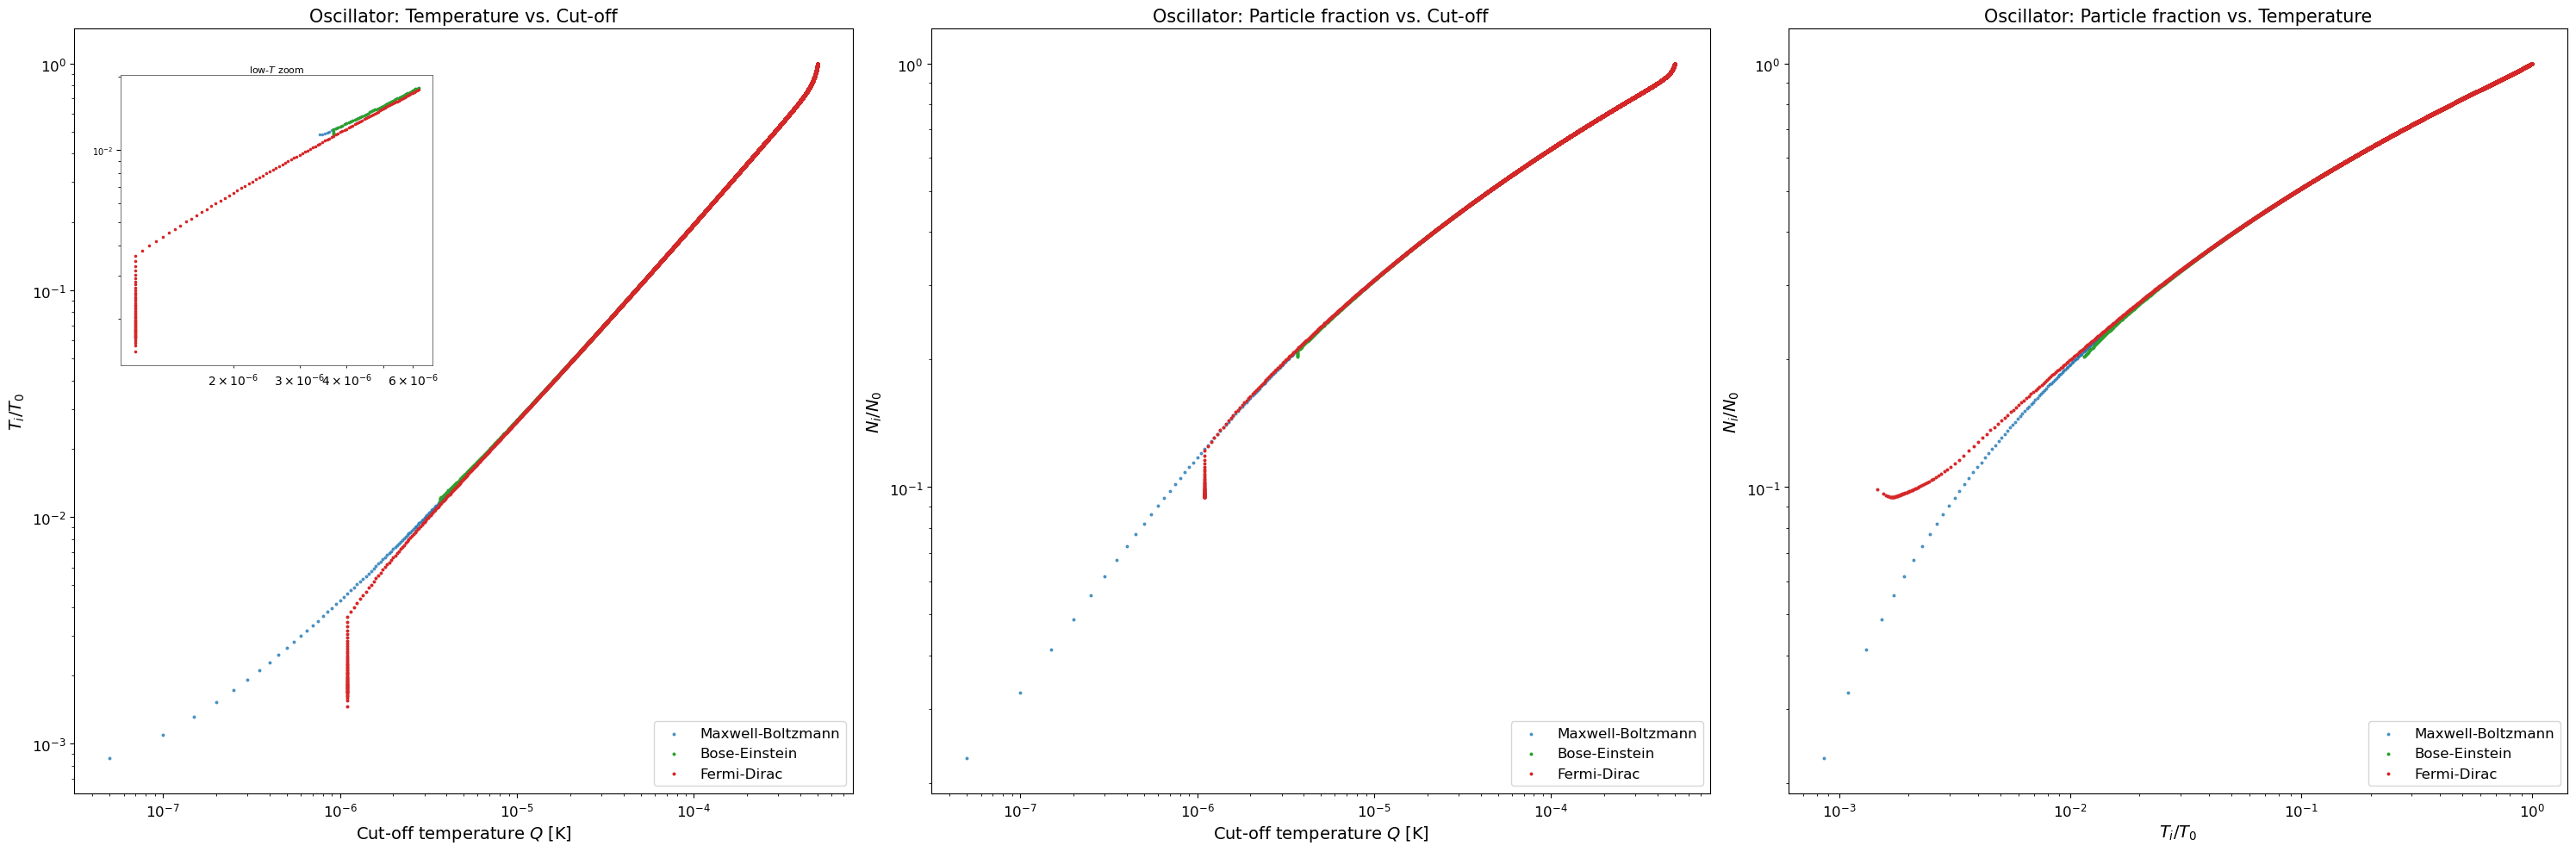

In [14]:
RUN_KW = dict(
    N0=1.0e7, T0=5.0e-5,
    Q0=5e-4, dQ_coarse=5e-8, n_steps_coarse=9999,
    dQ_fine=1e-20, n_steps_fine=200,
    zoom=True,
    alpha_floor_coarse=-1e-3,
    alpha_floor_fine=-1e-12,
    dps_coarse = 30,dps_fine=80,
)

results = {}
for t in TRAPS[3:4]:                       # slice e.g. TRAPS[:1] for a single trap
    results[t["key"]] = run_trap_session(
        t["trap"], name=t["name"], stem=t["key"],
        session=session, save=False,
        show_plot=True, save_fig=False, fig_dir=fig_dir,
        **RUN_KW,
    )

## Inspect the saved runs

`load_run` returns the full payload (`parameters`, `metadata`, `results`); the
schema version is checked on load. The final committed state is recorded in
`metadata` at save time.

In [ ]:
print(f"Sessions on disk: {[s.name for s in list_sessions('runs')]}")
print(f"\nRuns in current session ({session.name}):")
for path in list_runs(session, include_thermo=False):
    payload = load_run(path)
    meta    = payload["metadata"]
    params  = payload["parameters"]
    outcome = meta.get("outcome", {}) or {}
    trap_md = meta.get("trap", {}) or {}
    line = (f"  {path.name:28s} trap={trap_md.get('name','?'):<12s} "
            f"sign={params.get('sign', 0):>+2d} "
            f"steps={outcome.get('n_completed','?')}")
    zoom_md = meta.get("zoom")
    if zoom_md is not None:
        c = (zoom_md.get('coarse') or {}).get('n_completed', '?')
        f = zoom_md.get('fine')
        f = f.get('n_completed') if isinstance(f, dict) else 'skipped'
        line += f"  [zoom coarse={c} fine={f}]"
    print(line)

## Post-process equilibrium thermodynamics

Every rethermalised $(T_i, \mu_i)$ saved during evaporation is a genuine
equilibrium of the trap, so we compute equilibrium thermodynamics on each saved
state and write a paired `*_thermo.json` for BE, FD **and** MB. The thermo
notebook then picks these up automatically.

In [ ]:
for t in TRAPS:
    process_and_save_run(session / f"{t['key']}_bosons.json",   t["trap"], sign=+1)
    process_and_save_run(session / f"{t['key']}_fermions.json", t["trap"], sign=-1)
    process_and_save_mb_run(session / f"{t['key']}_mb.json",    t["trap"])

print("Thermo files written:")
for p in list_runs(session):
    if p.stem.endswith("_thermo"):
        print(f"  {p.relative_to(session)}")

## Where to go from here

- Open **`evap_cool_thermo_usage.ipynb`** to plot the equilibrium state
  functions and thermal coefficients (it auto-loads this session).
- Tune the mixed-trap geometry to reach degeneracy if you want BE/FD departures
  from MB.
- The cross-trap **dimensionless overlay** (one figure for everything) is a
  separate notebook; normalisation conventions are still being finalised.